In [1]:
library(msigdbr)
library(dplyr)
library(tibble)
library(purrr)
library(stringr)
library(clusterProfiler)
library(org.Mm.eg.db)
library(enrichplot)
library(ggplot2)


library(Seurat)
library(patchwork)
library(tidyverse) 

set.seed(1234)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




clusterProfiler v4.16.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan,
X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal
enrichment tool for interpreting omics data. The Innovation. 2021,
2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplify


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:ba

In [2]:
BiocManager::install("org.Mm.eg.db")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.21 (BiocManager 1.30.27), R 4.5.1 (2025-06-13)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'org.Mm.eg.db'”
Old packages: 'ade4', 'arrow', 'BBmisc', 'bedr', 'benchmarkmeData',
  'BiocGenerics', 'BiocParallel', 'blob', 'bmp', 'bookdown', 'broom',
  'BUSpaRse', 'Cairo', 'car', 'carData', 'checkmate', 'cicero', 'circlize',
  'circular', 'clock', 'clue', 'ClusterR', 'concaveman', 'cubature', 'DBI',
  'dbplyr', 'dbscan', 'DDRTree', 'devtools', 'DiceKriging', 'distributional',
  'doFuture', 'doRNG', 'downlit', 'dtplyr', 'dunn.test', 'dyngen', 'e1071',
  'emmeans', 'factoextra', 'FactoMineR', 'fansi', 'fastmatch', 'fastmatrix',
  'feather', 'flashClust', 'forcats', 'forecast', 'fs', 'FSA', 'futi

In [3]:
install.packages("ontologyIndex")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# GO analysis
reference code: 
https://www.melbournebioinformatics.org.au/tutorials/tutorials/seurat-go/seurat-go/

In [4]:
library(org.Mm.eg.db)
library(ontologyIndex)

In [5]:
# Read GO file
go <- get_ontology("../../data/go/go.obo")
descendant_terms <- get_descendants(get_ontology("../../data/go/go.obo"), roots="GO:0002376")

# TIM data

In [6]:
data_int <- "../../results/sc_rna/05_TIM_subclustering/intermediate"

# Define directories
dir_fig <- "../../results/sc_rna/06_GO/figures"
dir_int <- "../../results/sc_rna/06_GO/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

In [7]:
TIM <- readRDS(file.path(data_int, "TIM.rds"))

In [8]:
TIM

An object of class Seurat 
16245 features across 4582 samples within 1 assay 
Active assay: RNA (16245 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

In [9]:
TIM_markers <- FindAllMarkers(
  TIM,
  only.pos = TRUE,
  min.pct = 0.25,
  logfc.threshold = 0.25
)

Calculating cluster 0_Macro_Reg

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Calculating cluster 1_Mono_IFN

Calculating cluster 2_Mono_Class

Calculating cluster 3_Neutrophil

Calculating cluster 4_cDC2

Calculating cluster 5_T_contam



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


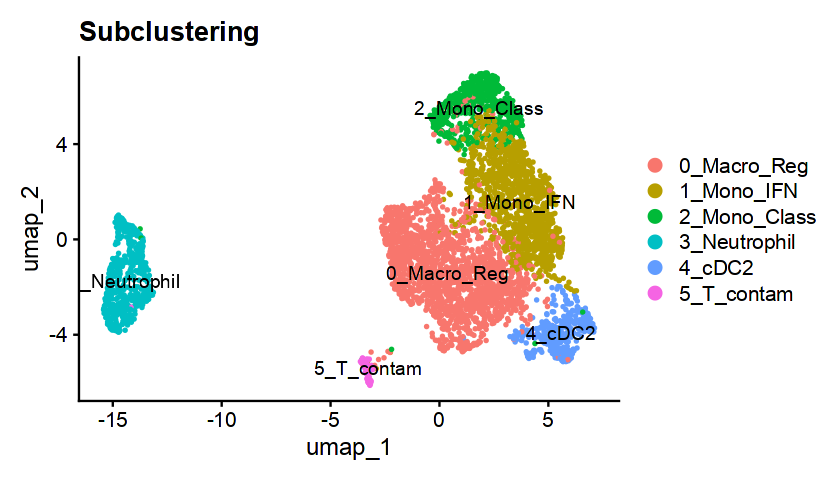

In [10]:
options(repr.plot.width = 7, repr.plot.height = 4)
p1 <- DimPlot(TIM, label = TRUE) + 
 ggtitle("Subclustering") 

p1

In [11]:
head(TIM)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5,SingleR_main,celltype_fine,celltype_broad,TIM_snn_res.0.1,TIM_snn_res.0.2,TIM_snn_res.0.3,TIM_snn_res.0.4,TIM_snn_res.0.5,TIM_snn_res.0.6,TIM_type
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0,0_Macro_Reg
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6,Neutrophils,Neutrophil,TIM,2,3,4,3,4,6,3_Neutrophil
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,3,5,Macrophages,MonoMac,TIM,0,1,0,4,5,3,1_Mono_IFN
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0,0_Macro_Reg
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,10,0,Macrophages,MonoMac,TIM,0,0,2,1,1,10,0_Macro_Reg
Day3_AAAGAACCACAAGTGG-1,day03,8090,2325,1.161928,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2,1_Mono_IFN
Day3_AAAGAACGTCGTGCCA-1,day03,3137,1365,1.785145,Day3,0,3,5,Monocytes,MonoMac,TIM,0,1,0,4,5,3,1_Mono_IFN
Day3_AAAGGATAGAGTTGCG-1,day03,9583,2499,2.671397,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2,1_Mono_IFN
Day3_AAAGGATGTCTTGCGG-1,day03,18933,3792,3.137379,Day3,1,1,0,Macrophages,MonoMac,TIM,0,0,2,1,1,1,0_Macro_Reg


# Filter gene

In [12]:
gene_list <- Features(TIM)
gene_name <- data.frame(gene_list)

# Find marker genes for each cluster

In [13]:
head(TIM_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
C3ar1,0.000000e+00,2.713003,0.820,0.196,0.000000e+00,0_Macro_Reg,C3ar1
Dab2,0.000000e+00,2.768737,0.809,0.268,0.000000e+00,0_Macro_Reg,Dab2
Lgmn,0.000000e+00,2.514869,0.955,0.536,0.000000e+00,0_Macro_Reg,Lgmn
Arg1,1.026219e-287,5.436283,0.540,0.078,1.667093e-283,0_Macro_Reg,Arg1
Gapdh,1.138712e-282,1.106480,0.999,0.973,1.849837e-278,0_Macro_Reg,Gapdh
Fcgr2b,1.326416e-274,1.472527,0.962,0.654,2.154764e-270,0_Macro_Reg,Fcgr2b


Idents(TIM) <- "TIM_snn_res.0.2"

- 0: Macro_Reg
- 1: Mono_IFN

In [14]:
Cluster0.markers <- TIM_markers[TIM_markers$cluster=="0_Macro_Reg" & TIM_markers$p_val_adj < 0.05, ]
Cluster1.markers <- TIM_markers[TIM_markers$cluster=="1_Mono_IFN" & TIM_markers$p_val_adj < 0.05, ]

Cluster0_filter.markers <- TIM_markers[TIM_markers$cluster=="0_Macro_Reg" & TIM_markers$p_val_adj < 0.05, ]
Cluster1_filter.markers <- TIM_markers[TIM_markers$cluster=="1_Mono_IFN" & TIM_markers$p_val_adj < 0.05, ]

# convert gene list
convert_gene0 <- gene_name %>% filter(!(gene_list %in% Cluster0.markers$gene)) 
convert_gene1 <- gene_name %>% filter(!(gene_list %in% Cluster1.markers$gene)) 

# Convert gene symbols to Enterz IDs

In [15]:
Cluster0_filter.gene_ids <- bitr(Cluster0_filter.markers$gene, fromType = "SYMBOL",
                                   toType = "ENTREZID", OrgDb = org.Mm.eg.db)
Cluster1_filter.gene_ids <- bitr(Cluster1_filter.markers$gene, fromType = "SYMBOL",
                                   toType = "ENTREZID", OrgDb = org.Mm.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(Cluster0_filter.markers$gene, fromType = "SYMBOL", toType = "ENTREZID", :
“2.44% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(Cluster1_filter.markers$gene, fromType = "SYMBOL", toType = "ENTREZID", :
“2.75% of input gene IDs are fail to map...”


In [16]:
write.csv(Cluster0_filter.gene_ids, file = file.path(dir_int, "Cluster0_gene_ids.csv"))
write.csv(Cluster1_filter.gene_ids, file = file.path(dir_int, "Cluster1_gene_ids.csv"))

# Cluster 0

In [17]:
Cluster0_filter.ego <- enrichGO(gene = Cluster0_filter.gene_ids$ENTREZID, 
                        OrgDb = org.Mm.eg.db, 
                        ont = "BP", # biological process
                        pAdjustMethod = "BH", 
                        pvalueCutoff = 0.05, 
                        qvalueCutoff = 0.05, 
                        readable = TRUE)

In [18]:
Cluster0_filter.ego@result <- Cluster0_filter.ego@result[Cluster0_filter.ego@result$ID %in% descendant_terms,]

In [19]:
Cluster0_filter.ego.simplify <- simplify(Cluster0_filter.ego)

# Cluster1

In [20]:
Cluster1_filter.ego <- enrichGO(gene = Cluster1_filter.gene_ids$ENTREZID, 
                        OrgDb = org.Mm.eg.db, 
                        ont = "BP", # biological process
                        pAdjustMethod = "BH", 
                        pvalueCutoff = 0.05, 
                        qvalueCutoff = 0.05, 
                        readable = TRUE)

In [21]:
Cluster1_filter.ego@result <- Cluster1_filter.ego@result[Cluster1_filter.ego@result$ID %in% descendant_terms,]

In [22]:
Cluster1_filter.ego.simplify <- simplify(Cluster1_filter.ego)

# Cluster 0 and 1

In [23]:
p0dot<-dotplot(Cluster0_filter.ego.simplify, showCategory=10, title="Enriched in Cluster 0")
p1dot<-dotplot(Cluster1_filter.ego.simplify, showCategory=10, title="Enriched in Cluster 1")

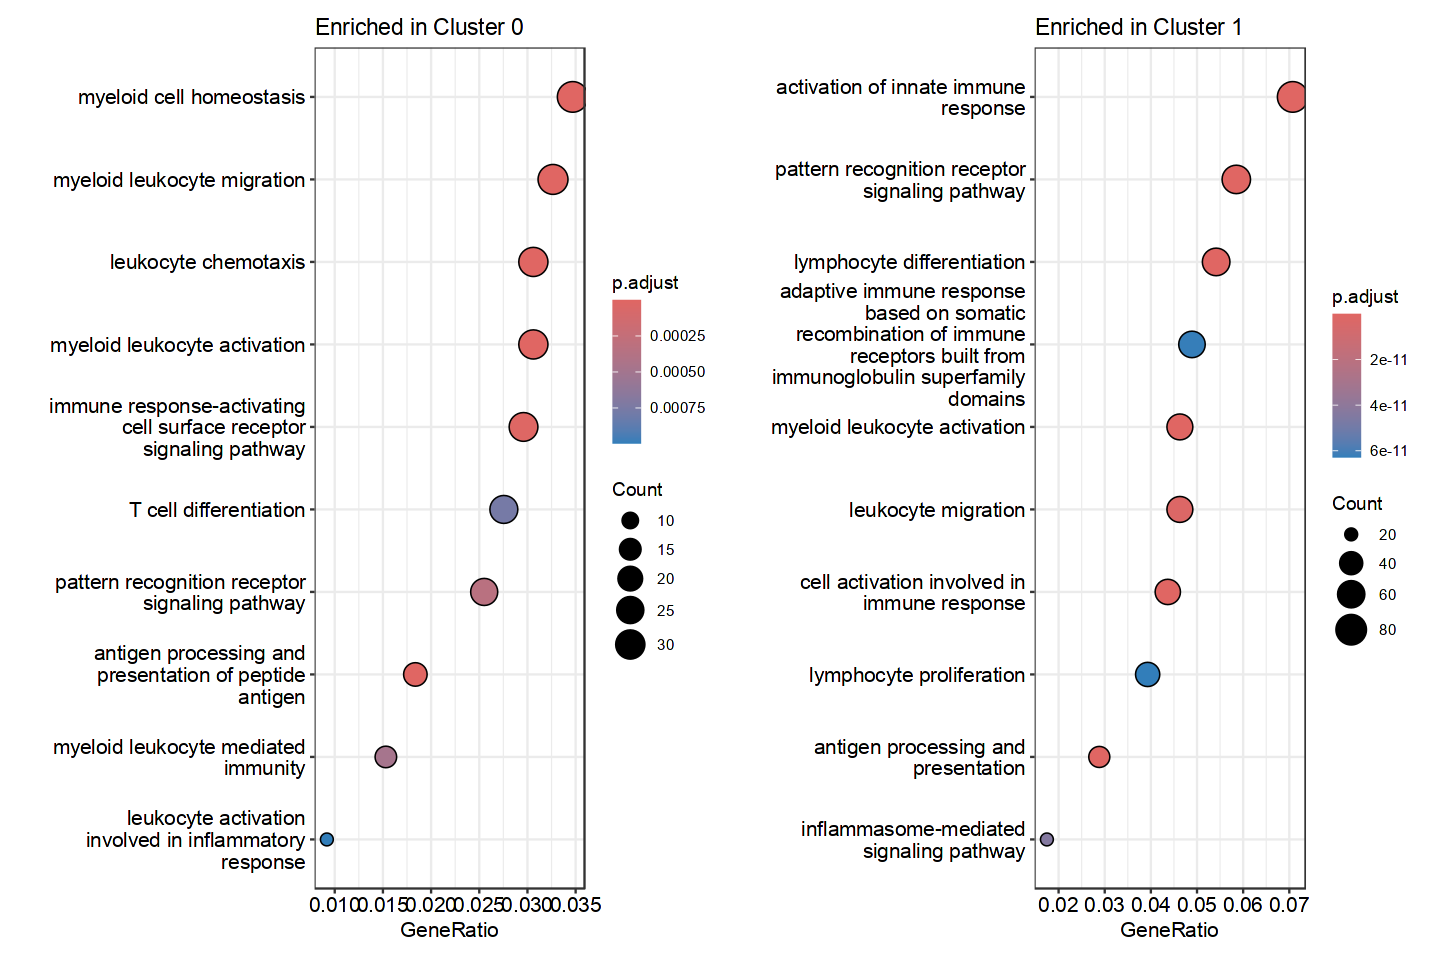

In [24]:
options(repr.plot.width = 12, repr.plot.height = 8)
p0dot+p1dot

In [25]:
p0bar<-barplot(Cluster0_filter.ego.simplify, showCategory=10, title="Enriched in Cluster 0")
p1bar<-barplot(Cluster1_filter.ego.simplify, showCategory=10, title="Enriched in Cluster 1")

Warning message in fortify(object, showCategory = showCategory, by = x, ...):
“Arguments in `...` must be used.
✖ Problematic argument:
• by = x
ℹ Did you misspell an argument name?”
Warning message in fortify(object, showCategory = showCategory, by = x, ...):
“Arguments in `...` must be used.
✖ Problematic argument:
• by = x
ℹ Did you misspell an argument name?”


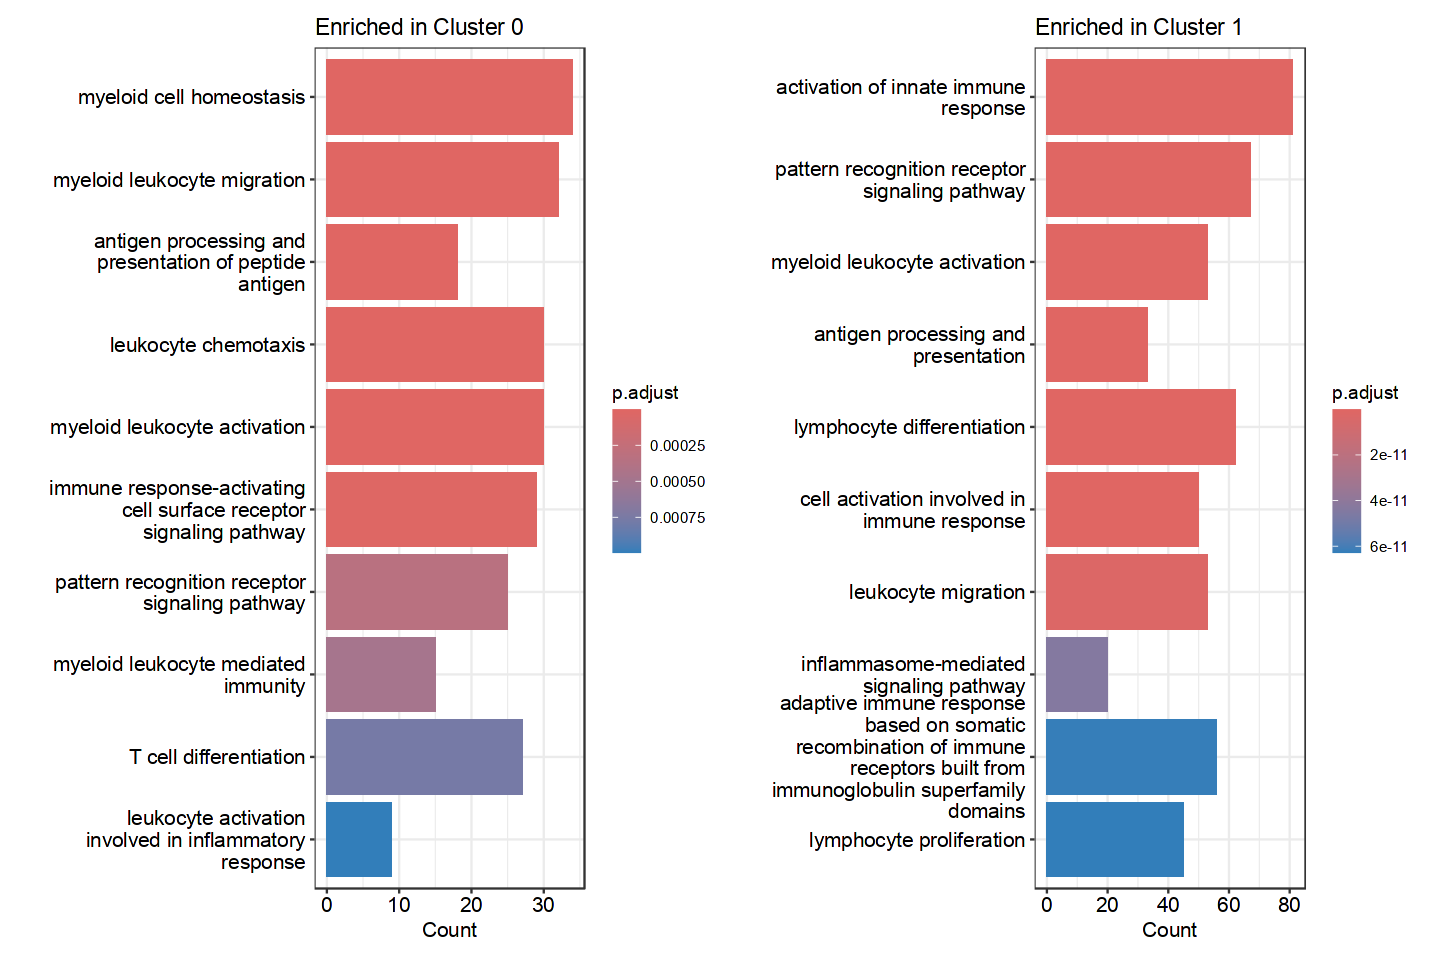

In [26]:
options(repr.plot.width = 12, repr.plot.height = 8)
p0bar+p1bar

In [27]:
ggsave(file = file.path(dir_fig, "cluster0_barplot_highdpi.jpeg"), plot = p0bar, width = 6, height = 8, dpi = 1200)
ggsave(file = file.path(dir_fig, "cluster1_barplot_highdpi.jpeg"), plot = p1bar, width = 6, height = 8, dpi = 1200)

ggsave(file = file.path(dir_fig, "cluster0_barplot_highdpi.pdf"), plot = p0dot, width = 6, height = 8, dpi = 1200)
ggsave(file = file.path(dir_fig, "cluster1_barplot_highdpi.pdf"), plot = p1dot, width = 6, height = 8, dpi = 1200)